# ANOVA : Analysis Of Variance
- Used to compare multiple means
- It uses within sample sum of squares and between sample sum of squares
- F Statistic is Used

- H0 : All means are same
- H1 : All are not same ( At least one is different ) 

## One Way ANOVA
<img align = 'left' src = 'one-way-ANOVA-formulas.png' style = 'width:600px; hieght:400px' />

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import style
style.use('ggplot')

from statsmodels.formula.api import ols
import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [9]:
data = pd.read_excel('ANOVA datasets.xlsx')
data.head(10)

,Paint,Hardness,Temp,Operator
0,Blend 2,14.9,30.3,1
1,Blend 3,13.0,30.9,2
2,Blend 4,15.0,30.5,2
3,Blend 1,17.0,29.4,3
4,Blend 1,13.9,30.0,3
5,Blend 3,16.4,29.6,1
6,Blend 1,10.4,29.6,2
7,Blend 2,3.2,29.9,2
8,Blend 2,1.9,28.9,2
9,Blend 2,7.3,28.6,1


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Paint     24 non-null     object 
 1   Hardness  24 non-null     float64
 2   Temp      24 non-null     float64
 3   Operator  24 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 896.0+ bytes


In [11]:
data.nunique()

Paint        4
Hardness    24
Temp        15
Operator     3
dtype: int64

In [12]:
print('Paints : ', data.Paint.unique())

Paints :  ['Blend 2' 'Blend 3' 'Blend 4' 'Blend 1']


<AxesSubplot:xlabel='Paint', ylabel='Hardness'>

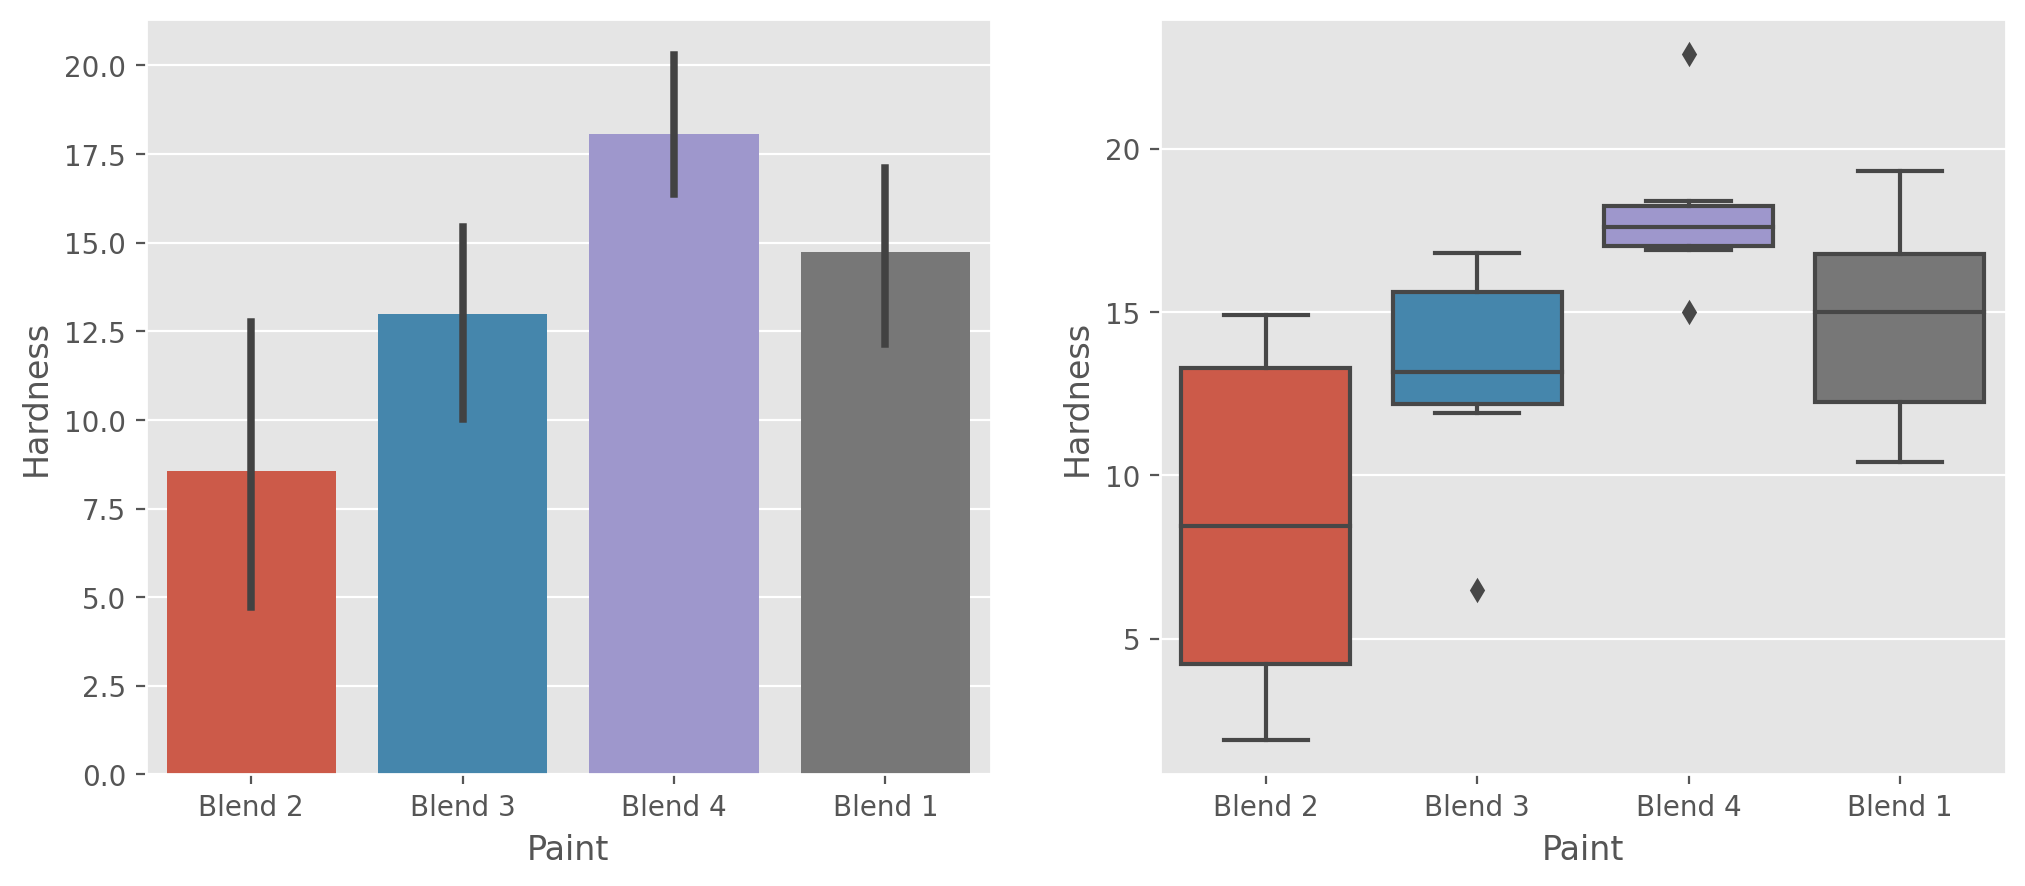

In [15]:
fig = plt.figure(figsize = (12,5), dpi = 200)
fig.add_subplot(1,2,1)
sns.barplot(data.Paint, data.Hardness)
fig.add_subplot(1,2,2)
sns.boxplot(data.Paint, data.Hardness)

In [16]:
model = ols('Hardness ~ C(Paint)', data = data).fit()

In [17]:
anova_tbl = sm.stats.anova_lm(model, typ = 1)
anova_tbl

,df,sum_sq,mean_sq,F,PR(>F)
C(Paint),3.0,281.697917,93.899306,6.017868,0.004297
Residual,20.0,312.068333,15.603417,NaN,NaN


In [18]:
# MSB
281.697917 / 3

93.89930566666668

In [19]:
# MSW
312.068333 / 20

15.60341665

In [29]:
# F-Statistic
f_statistic = 93.89930566666668 / 15.60341665
f_statistic

6.017868251096575

In [21]:
1 - stats.f.cdf(6.017868251096575, 3,20)

0.004296566537500546

In [27]:
alpha = 0.05
stats.f.ppf(1 - alpha,3,20)

3.09839121214078

In [30]:
f_critical = 3.10

if f_statistic > f_critical:
    print('Reject Null Hypothesis')
else:
    print('Fail to reject Null Hypothesis')

Reject Null Hypothesis


## Two Way ANOVA
<img align = 'left' src = 'two-way-anova.png' style = 'width:600px; hieght:400px' />

In [31]:
toothdf = pd.read_excel('ANOVA datasets.xlsx', sheet_name = 'ToothGrowth')
toothdf.head()

,len,supp,dose
0,4.2,VC,0.5
1,11.5,VC,0.5
2,7.3,VC,0.5
3,5.8,VC,0.5
4,6.4,VC,0.5


<AxesSubplot:xlabel='dose', ylabel='len'>

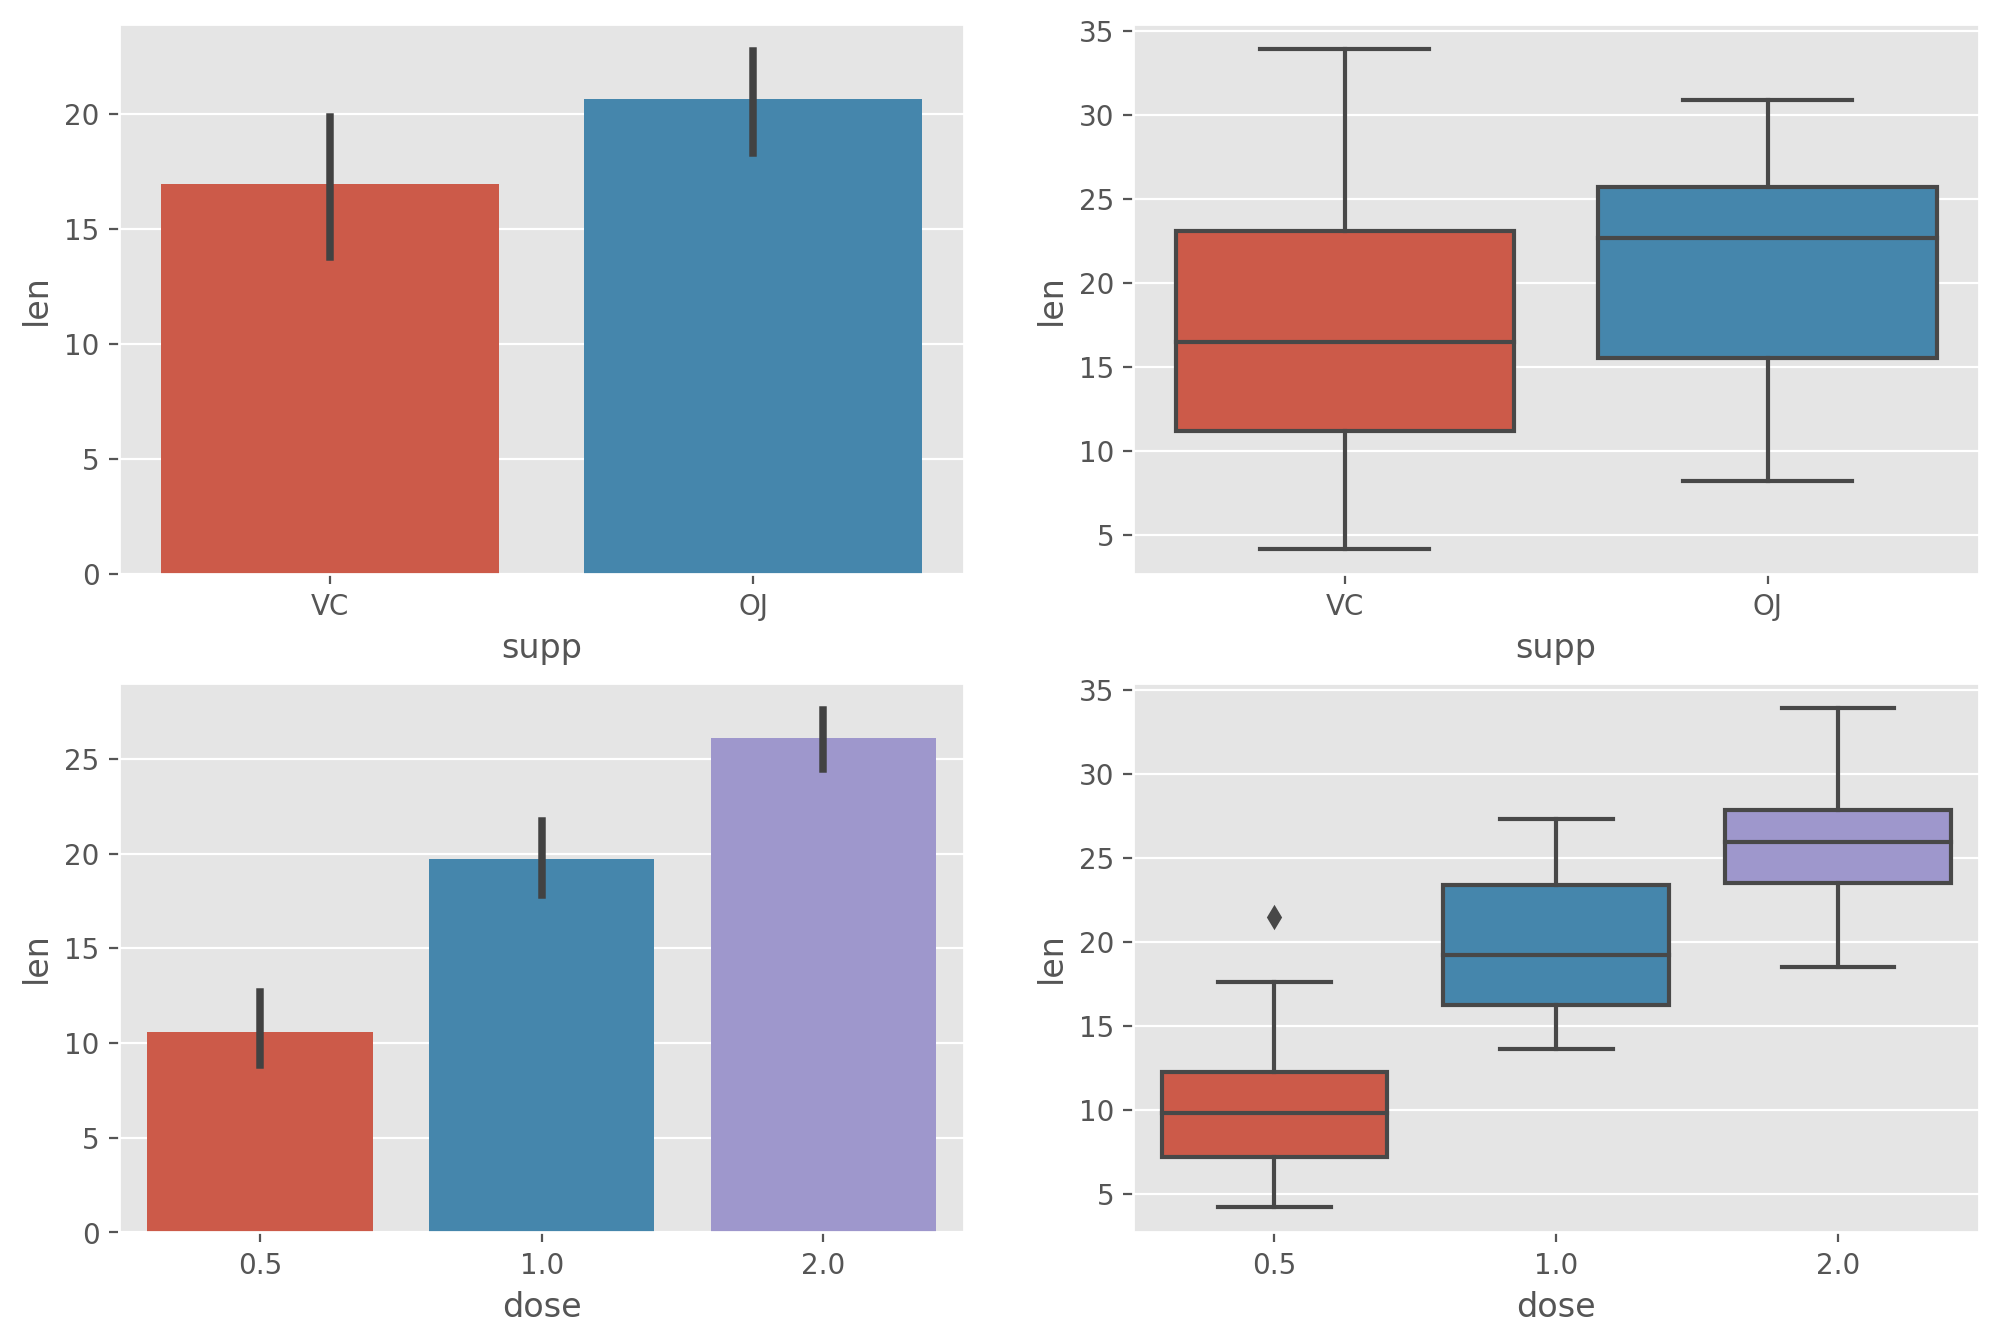

In [34]:
fig = plt.figure(figsize = (12,8), dpi = 200)
fig.add_subplot(2,2,1)
sns.barplot(toothdf.supp, toothdf.len)
fig.add_subplot(2,2,2)
sns.boxplot(toothdf.supp, toothdf.len)
fig.add_subplot(2,2,3)
sns.barplot(toothdf.dose, toothdf.len)
fig.add_subplot(2,2,4)
sns.boxplot(toothdf.dose, toothdf.len)

In [32]:
model = ols('len ~ C(supp) + C(dose) + C(supp) : C(dose)', data = toothdf).fit()
anova_tbl = sm.stats.anova_lm(model, typ = 2)
anova_tbl

,sum_sq,df,F,PR(>F)
C(supp),205.350000,1.0,15.571979,2.311828e-04
C(dose),2426.434333,2.0,91.999965,4.046291e-18
C(supp):C(dose),108.319000,2.0,4.106991,2.186027e-02
Residual,712.106000,54.0,NaN,NaN


In [38]:
F_row = 15.571979
F_col = 91.999965
F_interaction = 4.106991

p_row = 1 - stats.f.cdf(F_row, 1,54)
p_col = 1 - stats.f.cdf(F_col, 2,54)
p_int = 1 - stats.f.cdf(F_interaction, 2, 54)

print(p_row)
print(p_col)
print(p_int)

0.00023118285265066874
1.1102230246251565e-16
0.02186027074878405


# =====================================

# Topics Covered
### Descriptive Statistics
    - Measures of central tendency
    - Measures of dispersion
    - Z Score
    - Outlier detection
    - Skewness
    - Correlation
    - Visualization
    
### Probability
    - Terms and definations
    - Types of Events
    - Probability
    - Conditional Probability
    - Multiplication Theorem
    - Theorem of Total Probability
    - Bayes Theorem
    
    - Random variables
    - Mean / Expectation of random variables
    - Variance of Random Varibales
    - Descrete and Continuous random variables
    
    - Probability Distributions
        1. Decrete Probability Distributions
        2. Continuous Probability Distributions
        
### Inferential Statistics
    - Central Limit Theorem
    - Confidence Intervals
    - Hypothesis testing
        - Null and Alternate hypothesis
        - Steps involved in hypothesis testing
        - P - Value , Significance Level
        - Critical / Rejection Region, Acceptance region, Critical Value
        - Z test and Z statistic
        - Chi Square Test chi square statistic
        - ANOVA and F statistic